In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay


In [ ]:
df = pd.read_csv("csv/cs-training.csv")
df.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df.shape

(150000, 11)

In [8]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [9]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

We analyze how much those Nan represent.

In [11]:
(df.isnull().sum() / len(df)) * 100

SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

Missing Values and Data Imputation

Missing values were found in MonthlyIncome and NumberOfDependents. Since machine learning models cannot handle NaN values, data imputation was applied.
MonthlyIncome was filled with the median to reduce the effect of outliers, while NumberOfDependents was filled with 0, assuming missing values indicate no reported dependents.
After this step, the dataset contains no missing values.
This approach corresponds to univariate imputation, a common and simple strategy for handling missing numerical data, and it is appropriate here since the proportion of missing values is relatively small.

In [12]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

In [13]:
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [14]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Target Variable

The variable SeriousDlqin2yrs is selected as the target variable because it represents the outcome we want to predict. It indicates whether a person experienced a serious delinquency (default) within the next two years.

In [ ]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Class Distribution

The distribution of the target variable shows a clear class imbalance. Most observations correspond to class 0 (no delinquency), while a much smaller proportion corresponds to class 1 (serious delinquency). This imbalance is important because it can affect the performance of machine learning models, which may become biased toward predicting the majority class.

<Axes: xlabel='SeriousDlqin2yrs'>

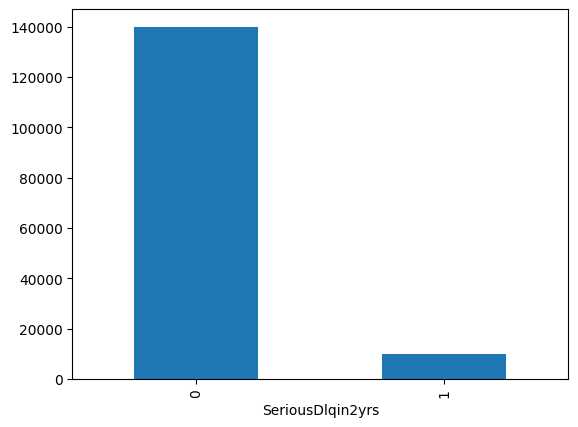

In [17]:
df["SeriousDlqin2yrs"].value_counts().plot(kind="bar")

Separate variables and target

In [18]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

The target variable SeriousDlqin2yrs is highly imbalanced.
Around 93% of the observations correspond to class 0 (no default) and 7% to class 1 (default).
Therefore, stratified train-test splitting was used to preserve the class distribution in both training and test sets.

A baseline logistic regression model was trained without applying any imbalance handling technique. This provides a reference point to evaluate how class imbalance affects model performance, especially for the minority class.

/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== BASELINE MODEL ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.56      0.05      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.75      0.52      0.53     30000
weighted avg       0.91      0.93      0.91     30000

ROC-AUC: 0.714281486852613


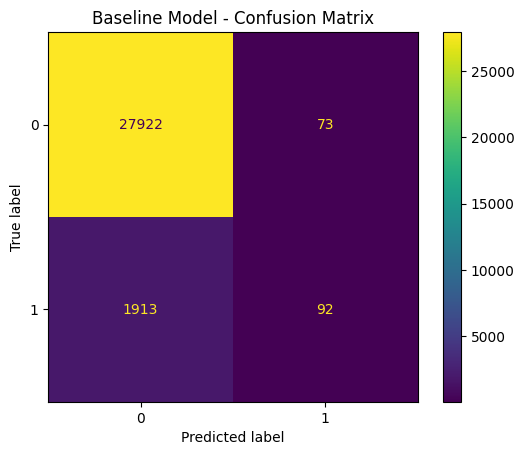

In [ ]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE MODEL ===")
print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline)
plt.title("Baseline Model - Confusion Matrix")
plt.show()

Baseline Model Performance

The baseline logistic regression model achieves high overall accuracy (around 93%), mainly because the dataset is highly imbalanced. However, the recall for the minority class (default) is very low (around 5%), meaning that the model fails to detect most default cases. This highlights the impact of class imbalance and motivates the use of techniques such as class weighting or oversampling.

A second logistic regression model was trained using class_weight="balanced" to penalize errors in the minority class more strongly. This helps the model pay more attention to default cases.

=== CLASS WEIGHT = BALANCED ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.90     27995
           1       0.22      0.62      0.33      2005

    accuracy                           0.83     30000
   macro avg       0.60      0.73      0.62     30000
weighted avg       0.92      0.83      0.86     30000

ROC-AUC: 0.806366865476067


/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


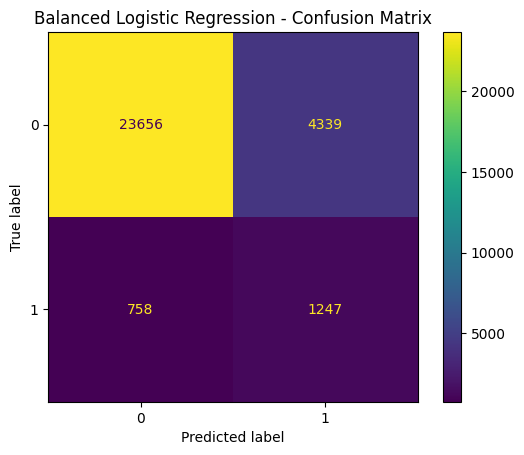

In [25]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)
y_proba_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("=== CLASS WEIGHT = BALANCED ===")
print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_balanced))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced)
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

Balanced Logistic Regression

Using class_weight="balanced" significantly improves the model's ability to detect the minority class (default). The recall for class 1 increases substantially compared to the baseline model, meaning that more default cases are correctly identified. However, this improvement comes at the cost of an increase in false positives and a lower overall accuracy. This trade-off is common when dealing with imbalanced datasets.

In [ ]:
#Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original distribution in y_train:")
print(y_train.value_counts())

print("\nDistribution after SMOTE:")
print(y_train_smote.value_counts())

Distribución original en y_train:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Distribución después de SMOTE:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


SMOTE Oversampling

SMOTE was applied only to the training set in order to balance the class distribution. The original training data contained significantly fewer observations of the minority class (default). After applying SMOTE, synthetic samples were generated for the minority class until both classes had the same number of observations.

=== LOGISTIC REGRESSION + SMOTE ===
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     27995
           1       0.13      0.62      0.22      2005

    accuracy                           0.70     30000
   macro avg       0.55      0.66      0.52     30000
weighted avg       0.91      0.70      0.78     30000

ROC-AUC: 0.7100121993640653


/home/adrianarodriguez/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


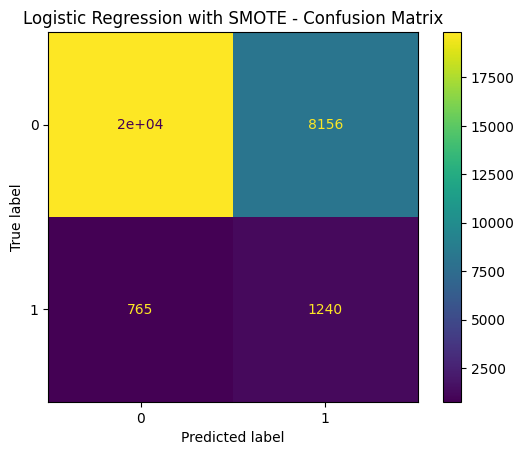

In [27]:
smote_model = LogisticRegression(max_iter=1000, random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION + SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)
plt.title("Logistic Regression with SMOTE - Confusion Matrix")
plt.show()

Logistic Regression with SMOTE

SMOTE was applied to balance the training data by generating synthetic samples for the minority class. The model trained on the SMOTE dataset shows a similar recall for the minority class compared to the class-weighted model. However, it produces a significantly larger number of false positives, which reduces the overall accuracy. This suggests that, for this dataset, using class weights may provide a better balance between detecting defaults and avoiding excessive false alarms.

In [29]:
results = pd.DataFrame({
    "Model": ["Baseline", "Class Weight Balanced", "SMOTE"],
    "Precision (class 1)": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_smote)
    ],
    "Recall (class 1)": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_smote)
    ],
    "F1-score (class 1)": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_smote)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_score(y_test, y_proba_balanced),
        roc_auc_score(y_test, y_proba_smote)
    ]
})

results

,Model,Precision (class 1),Recall (class 1),F1-score (class 1),ROC-AUC
0,Baseline,0.557576,0.045885,0.084793,0.714281
1,Class Weight Balanced,0.223237,0.621945,0.328547,0.806367
2,SMOTE,0.131971,0.618454,0.217525,0.710012


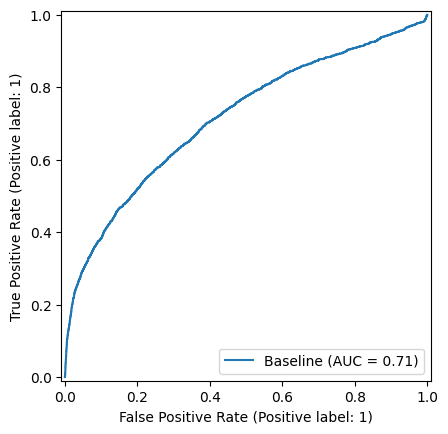

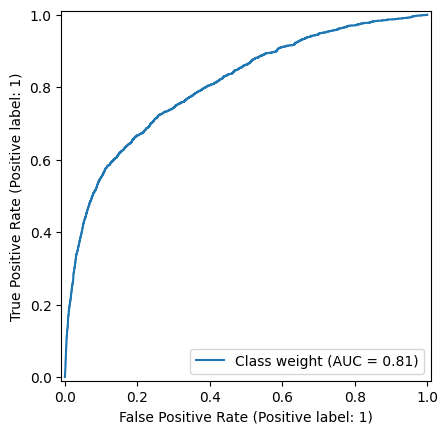

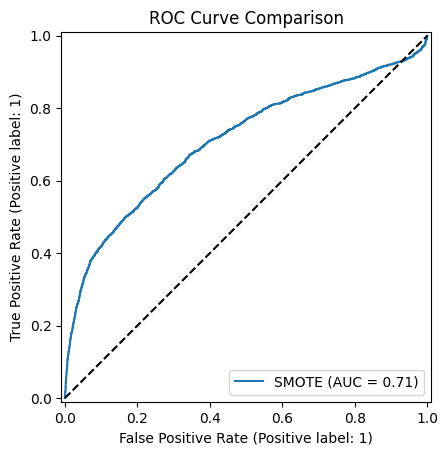

In [31]:
RocCurveDisplay.from_predictions(y_test, y_proba_baseline, name="Baseline")
RocCurveDisplay.from_predictions(y_test, y_proba_balanced, name="Class weight")
RocCurveDisplay.from_predictions(y_test, y_proba_smote, name="SMOTE")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.show()

Final Comparison of Models

The three approaches show clear differences in performance on the minority class (defaults).

The baseline model performs poorly at detecting defaults. Although it achieves reasonable precision (0.56), the recall is extremely low (0.05), meaning that most default cases are missed. This happens because the dataset is highly imbalanced and the model is biased toward predicting the majority class.

The class-weight balanced model significantly improves the detection of the minority class. Recall increases to about 0.62, and the ROC-AUC reaches 0.81, which is the best performance among the tested approaches. This indicates that weighting the minority class helps the model learn patterns associated with defaults without altering the original data distribution.

The SMOTE model also increases recall (0.62), but it introduces more false positives, resulting in lower precision and a lower ROC-AUC (0.71). In this case, oversampling did not improve overall performance compared to the class-weight approach.

Overall, the class-weight balanced logistic regression provides the best trade-off between detecting defaults and maintaining overall model performance, making it the preferred approach for this dataset.

Vale ahora del Unit 3 de Imbalanced data se podria hacer Under-samplig y tecnicas combinadas, y tbm algo con el ajuste del threshold en el modelo que me salio bien con el class_weight(el 2).

Falta añadir todo el tema 2.